 ## 03 – ARIMA & SARIMA Modeling

This notebook focuses on:

- Stationarity testing
- Differencing techniques
- ACF & PACF interpretation
- ARIMA modeling
- SARIMA modeling
- Residual diagnostics
- Forecasting

Goal: Build statistically sound time series models.

In [6]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_ng_consumption

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

In [3]:
df = load_ng_consumption("../data/NaturalGasConsumption.xls")

df.head()

,U.S. Natural Gas Total Consumption (Bcf),Year,Month,Quarter
Date,,,,
2001-01-01,2676.998,2001,1,1
2001-02-01,2309.464,2001,2,1
2001-03-01,2246.633,2001,3,1
2001-04-01,1807.170,2001,4,2
2001-05-01,1522.382,2001,5,2


# 📈 Stationarity in Time Series

## What is Stationarity?

A time series is **stationary** if its statistical properties remain constant over time.

This means:

1. The **mean** does not change over time.
2. The **variance** remains constant.
3. The **covariance** between time periods depends only on the lag, not the actual time.

---

## Why is Stationarity Important?

Models like **ARIMA** assume the time series is stationary.

If the data is not stationary:
- Model parameters become unreliable
- Forecasts become inaccurate
- Statistical tests may give misleading results

---

## Types of Stationarity

### 1️⃣ Strict Stationarity
The entire distribution of the series does not change over time.

(This is rarely required in practice.)

### 2️⃣ Weak (Covariance) Stationarity
Only the first two moments remain constant:
- Constant mean
- Constant variance
- Autocovariance depends only on lag

Most time series models assume weak stationarity.

---

## What Makes a Series Non-Stationary?

A time series is typically non-stationary if it has:

- 📈 Trend (upward or downward movement)
- 🔁 Seasonality
- 📊 Changing variance (heteroscedasticity)
- Structural breaks

In [9]:
def adfuller_test_func(time_series):

    print('Augmented Dickey-Fuller Test:')
    adfuller_result = adfuller(time_series)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value,label in zip(adfuller_result,labels):
        print(label+' : '+str(value) )
        
    if adfuller_result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

adfuller_test_func(df['U.S. Natural Gas Total Consumption (Bcf)'])

Augmented Dickey-Fuller Test:
ADF Test Statistic : 0.09018419735588984
p-value : 0.9653844984624933
#Lags Used : 14
Number of Observations Used : 261
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


# 🔄 Differencing in Time Series

## What is Differencing?

Differencing is a technique used to make a time series **stationary**.

It works by subtracting the previous observation from the current observation.

Mathematically:

Y′ₜ = Yₜ − Yₜ₋₁

This removes trend and stabilizes the mean of the series.

---

## Why Do We Use Differencing?

Time series models like ARIMA require the data to be stationary.

If the series has:
- 📈 Trend
- 🔁 Seasonality
- Changing mean over time

Differencing helps remove these patterns.

---

## 1️⃣ First-Order Differencing

Removes linear trend.

Formula:

Y′ₜ = Yₜ − Yₜ₋₁

If the differenced series passes the ADF test → d = 1

<Axes: xlabel='Date'>

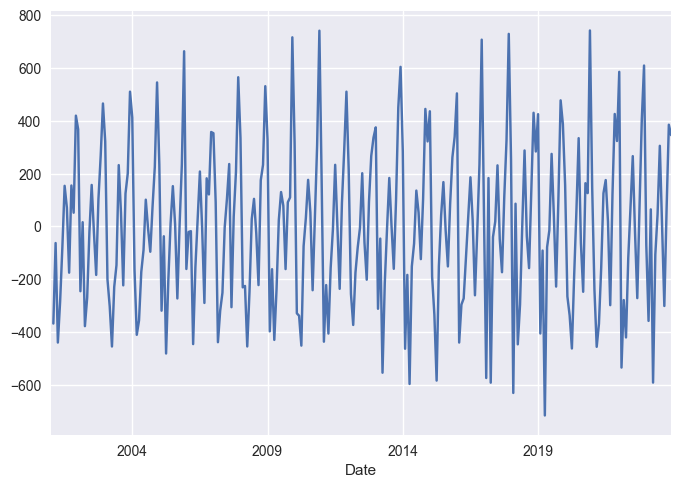

In [7]:
df['First_Difference'] = df['U.S. Natural Gas Total Consumption (Bcf)'] - df['U.S. Natural Gas Total Consumption (Bcf)'].shift(1)
df['First_Difference'].plot()

In [10]:
adfuller_test_func(df['First_Difference'].dropna())

Augmented Dickey-Fuller Test:
ADF Test Statistic : -5.759011491591223
p-value : 5.730091714560326e-07
#Lags Used : 13
Number of Observations Used : 261
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


# 📊 ACF and PACF for ARIMA & SARIMA


## What is ACF?

ACF (Autocorrelation Function) measures the correlation between a time series and its past values.

It tells us:
- How strongly Yₜ is correlated with Yₜ₋₁, Yₜ₋₂, Yₜ₋₃, etc.

Used to identify:  
➡ Moving Average (MA) order → q

---

## What is PACF?

PACF (Partial Autocorrelation Function) measures the correlation between Yₜ and Yₜ₋ₖ 
after removing the effect of intermediate lags.

Used to identify:  
➡ Autoregressive (AR) order → p

---

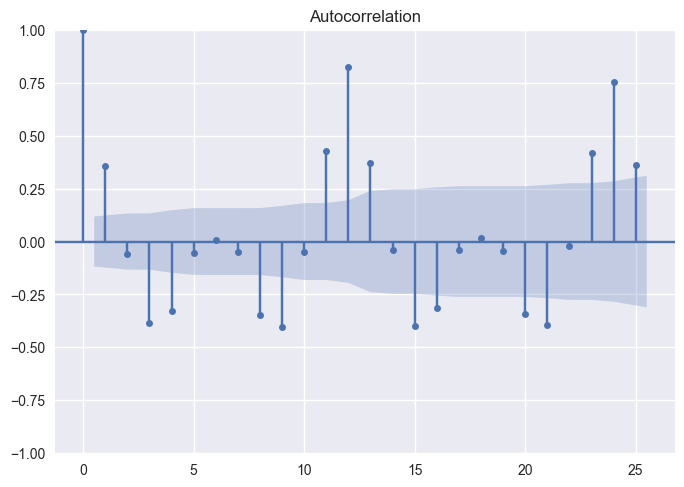

In [6]:
fig_first_acf = plot_acf(df['First_Difference'].dropna())

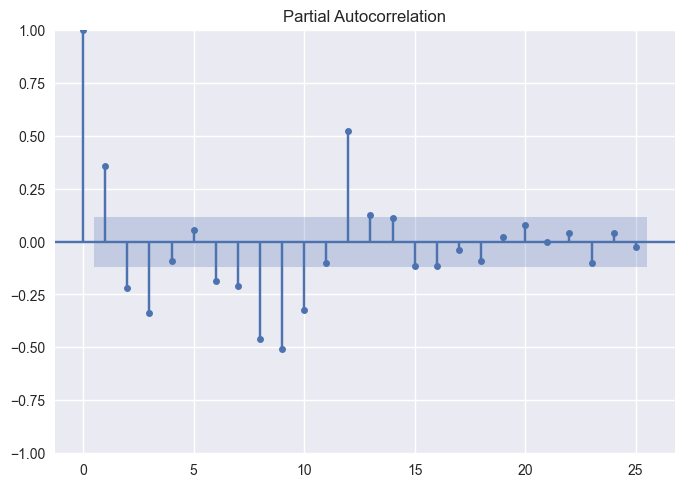

In [7]:
fig_first_pacf = plot_pacf(df['First_Difference'].dropna())

# 📊 ACF & PACF Interpretation (After First Differencing)

## Context

- Original series: Non-stationary
- Applied first differencing → d = 1
- ADF test confirms stationarity
- ACF and PACF plotted on first-differenced data

---

# 🔎 ACF Interpretation

### Observations:

1. Significant spike at lag 12
2. Significant spike at lag 24
3. Alternating positive and negative correlations
4. Slow decay at seasonal lags

### Interpretation:

- Strong annual seasonality (monthly data → period = 12)
- Seasonal pattern remains after first differencing
- Indicates need for **seasonal differencing**

Conclusion:

Seasonal differencing required → D = 1  
Seasonal period → s = 12  

---

# 🔎 PACF Interpretation

### Observations:

1. Significant spike at lag 1
2. Strong spike at lag 12
3. Remaining lags mostly insignificant

### Interpretation:

- Lag 1 spike → AR(1) component likely → p = 1
- Lag 12 spike → Seasonal AR(1) likely → P = 1

---

# 🚨 Key Insight

Even though first differencing removed the trend:

- Seasonality still exists
- Strong seasonal spikes at lag 12 confirm this

Therefore, model should include:

- d = 1 (non-seasonal differencing)
- D = 1 (seasonal differencing)
- s = 12 (monthly data)

---

# 🎯 Preliminary Model Suggestion

Based on current plots:

SARIMA(1,1,0)(1,1,0,12)

However, after seasonal differencing, ACF may show seasonal MA behavior as well, potentially leading to:

SARIMA(1,1,1)(1,1,1,12)

---

# 📌 Next Step

Apply seasonal differencing.


In [13]:
df['Seasonal_Difference_after_first'] = df['U.S. Natural Gas Total Consumption (Bcf)'].diff(1).diff(12)
adfuller_test_func(df['Seasonal_Difference_after_first'].dropna())

Augmented Dickey-Fuller Test:
ADF Test Statistic : -6.892120416599282
p-value : 1.3473158475223893e-09
#Lags Used : 14
Number of Observations Used : 248
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


# 📈 SARIMA Model – Detailed Explanation

## 1️⃣ What is SARIMA?

SARIMA stands for:

Seasonal AutoRegressive Integrated Moving Average

It extends the ARIMA model by adding a seasonal component.

The full model is written as:

SARIMA(p, d, q)(P, D, Q, s)

Where:

- (p, d, q) → Non-seasonal components
- (P, D, Q, s) → Seasonal components

---

# 2️⃣ How SARIMA Works Conceptually

SARIMA models a time series using:

1. Past values of the series (Autoregression)
2. Past forecast errors (Moving Average)
3. Differencing to remove trend
4. Seasonal patterns

It combines:

- AR (memory of past values)
- MA (memory of past shocks)
- Differencing (removes trend)
- Seasonal repetition patterns

Mathematically, it models:

Current value =
  Weighted past values
+ Weighted past errors
+ Seasonal memory
+ Seasonal error memory

---

# 3️⃣ Understanding the Parameters

## 🔹 Non-Seasonal Parameters (p, d, q)

### 1️⃣ p → Autoregressive Order (AR)

- Number of past values used.
- Determined using PACF.
- If PACF has a strong spike at lag 1 → p = 1.

Interpretation:
> The current month depends on the previous month.

---

### 2️⃣ d → Differencing Order

- Number of times the series is differenced to become stationary.
- Determined using ADF test.

If:
- Original series is non-stationary
- First difference is stationary

Then:
d = 1

Interpretation:
> We removed the trend once.

---

### 3️⃣ q → Moving Average Order (MA)

- Number of past forecast errors included.
- Determined using ACF.
- If ACF shows a spike at lag 1 → q = 1.

Interpretation:
> Current value depends on last period's shock/error.

---

# 4️⃣ Seasonal Parameters (P, D, Q, s)

## 🔹 s → Seasonal Period

For monthly data:
s = 12

Because pattern repeats yearly.

---

### 1️⃣ D → Seasonal Differencing

- Removes repeating yearly pattern.
- Determined by strong spikes at lag 12 in ACF.
- If seasonal pattern remains after first differencing:

D = 1

Interpretation:
> We removed yearly seasonal structure once.

---

### 2️⃣ P → Seasonal AR

- Determined using PACF at lag 12.
- Strong spike at lag 12 → P = 1.

Interpretation:
> This January depends on last January.

---

### 3️⃣ Q → Seasonal MA

- Determined using ACF at lag 12.
- Strong spike at lag 12 → Q = 1.

Interpretation:
> This month’s shock relates to shock from same month last year.

---

# 5️⃣ How We Chose Parameters for Natural Gas Data

### Step 1: ADF Test

Original series → Non-stationary  
First difference → Stationary  

So:
d = 1

---

### Step 2: ACF of First-Differenced Data

Observed:
- Strong spikes at lag 12 and 24
- Clear seasonal pattern

So:
D = 1
s = 12

---

### Step 3: PACF Plot

Observed:
- Significant spike at lag 1 → p = 1
- Significant spike at lag 12 → P = 1

---

### Step 4: ACF Plot

Observed:
- Some significance at lag 1 → q likely 0 or 1
- Strong spike at lag 12 → Q = 1

---

# 6️⃣ Final Model Considered

SARIMA(1,1,1)(1,1,1,12)

Meaning:

- Remove trend once (d = 1)
- Remove seasonal pattern once (D = 1)
- Include AR(1) memory
- Include MA(1) shock
- Include seasonal AR(1)
- Include seasonal MA(1)
- Seasonal cycle = 12 months

---

# 7️⃣ Why We Fit on Original Data

Even though we manually differenced to analyze:

We fit SARIMA on the original series because:

- The model internally applies differencing.
- It preserves correct likelihood estimation.
- It generates forecasts in original scale.

---

# 8️⃣ Intuitive Interpretation for Our Use Case

Natural gas consumption:

- Has trend → handled by d = 1
- Has strong yearly seasonality → handled by D = 1
- Current month depends on last month → p = 1
- Current month influenced by last shock → q = 1
- January depends on last January → P = 1
- Seasonal shocks persist → Q = 1

Thus SARIMA captures:

Trend + Seasonality + Short-term memory + Seasonal memory

---

# 9️⃣ Final Takeaway

SARIMA works because it:

- Forces stationarity
- Models short-term autocorrelation
- Models seasonal repetition
- Accounts for shock persistence

It is ideal for monthly energy consumption data with strong yearly cycles.


Fitting candidate SARIMA models...

SARIMA(1, 1, 0)(1, 1, 0, 12) → AIC: 3179.81
SARIMA(1, 1, 1)(1, 1, 1, 12) → AIC: 3047.04
SARIMA(2, 1, 1)(1, 1, 1, 12) → AIC: 3048.39
SARIMA(1, 1, 1)(0, 1, 1, 12) → AIC: 3045.68

Model Comparison:
       order seasonal_order          AIC          BIC
3  (1, 1, 1)  (0, 1, 1, 12)  3045.677091  3059.746903
1  (1, 1, 1)  (1, 1, 1, 12)  3047.044619  3064.631883
2  (2, 1, 1)  (1, 1, 1, 12)  3048.392634  3069.497351
0  (1, 1, 0)  (1, 1, 0, 12)  3179.810547  3190.374930

Best Model:
order                 (1, 1, 1)
seasonal_order    (0, 1, 1, 12)
AIC                 3045.677091
BIC                 3059.746903
Name: 3, dtype: object
                                          SARIMAX Results                                           
Dep. Variable:     U.S. Natural Gas Total Consumption (Bcf)   No. Observations:                  276
Model:                       SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1518.839
Date:                           

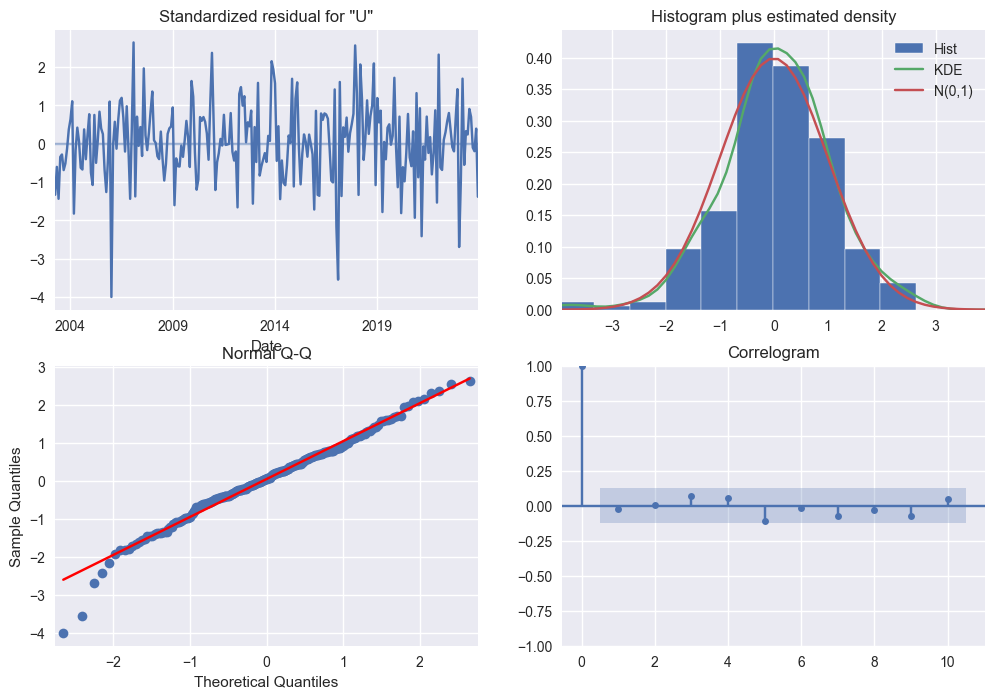

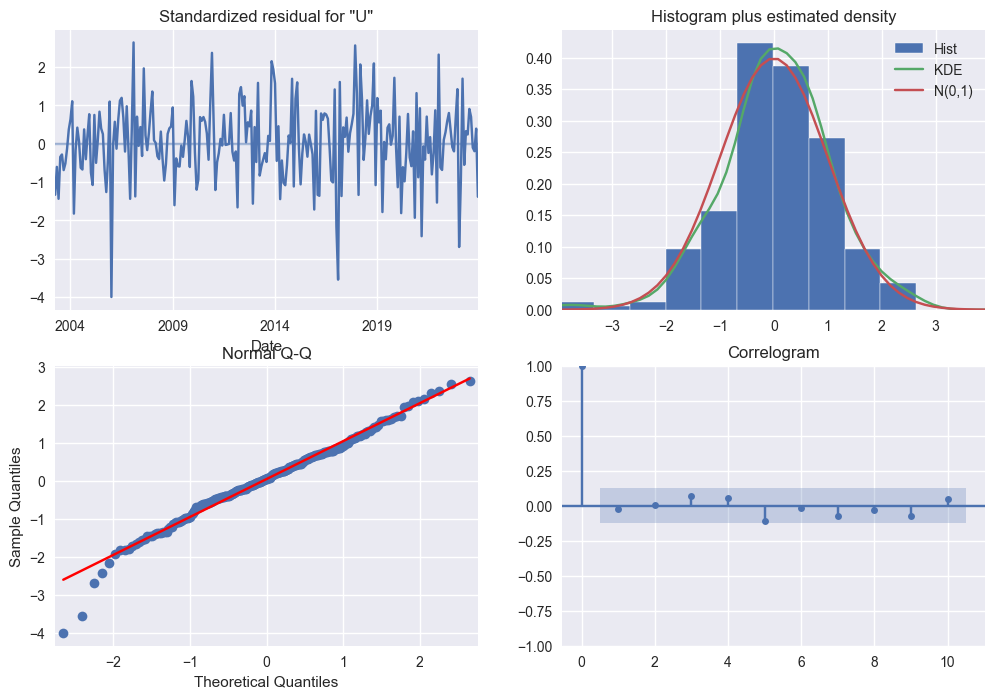

In [18]:
# Target series (original, NOT differenced)
y = df["U.S. Natural Gas Total Consumption (Bcf)"]

# Candidate SARIMA configurations
candidate_models = [
    (1,1,0, 1,1,0),
    (1,1,1, 1,1,1),
    (2,1,1, 1,1,1),
    (1,1,1, 0,1,1),
]

results_table = []

print("Fitting candidate SARIMA models...\n")

for (p,d,q,P,D,Q) in candidate_models:
    try:
        model = sm.tsa.statespace.SARIMAX(
            y,
            order=(p,d,q),
            seasonal_order=(P,D,Q,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted = model.fit(disp=False)
        
        results_table.append({
            "order": (p,d,q),
            "seasonal_order": (P,D,Q,12),
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
        
        print(f"SARIMA{(p,d,q)}{(P,D,Q,12)} → AIC: {fitted.aic:.2f}")
        
    except Exception as e:
        print(f"Model {(p,d,q)}{(P,D,Q,12)} failed")

# Compare models
results_df = pd.DataFrame(results_table).sort_values("AIC")
print("\nModel Comparison:")
print(results_df)

# Fit best model again
best = results_df.iloc[0]
print("\nBest Model:")
print(best)

best_model = sm.tsa.statespace.SARIMAX(
    y,
    order=best["order"],
    seasonal_order=best["seasonal_order"],
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_results = best_model.fit()

print(best_results.summary())

# Residual diagnostics
best_results.plot_diagnostics(figsize=(12,8))

# 📊 Akaike Information Criterion (AIC)

## 1️⃣ What is AIC?

AIC stands for **Akaike Information Criterion**.

It is a statistical metric used to compare competing models and determine which one best balances:

- Goodness of fit  
- Model complexity  

AIC does **not** measure absolute model quality.  
It only tells us which model is better *relative to other candidate models*.

---

# 2️⃣ Why Do We Need AIC?

When building time series models like SARIMA, we can choose many combinations of:

- p (AR terms)
- d (differencing)
- q (MA terms)
- P, D, Q (seasonal components)

Adding more parameters usually improves model fit.

However:

More parameters → More complexity → Risk of overfitting.

AIC penalizes unnecessary complexity.

---

# 3️⃣ The Formula

AIC is defined as:

AIC = -2 log(L) + 2k

Where:

- L = Likelihood of the model
- k = Number of estimated parameters

---

# 4️⃣ Understanding the Two Components

## 🔹 1. Model Fit (Likelihood Term)

-2 log(L)

This measures how well the model explains the observed data.

Better fit → Higher likelihood → Lower AIC

---

## 🔹 2. Complexity Penalty

2k

This penalizes the model for having too many parameters.

More parameters → Larger penalty → Higher AIC

---

# 5️⃣ What AIC Is Really Doing

AIC estimates the amount of **information loss** when using a model to approximate reality.

Lower AIC → Less information lost → Better model (among those tested)

It is derived from information theory and approximates the relative distance between the candidate model and the unknown true model.

---

# 6️⃣ How to Interpret AIC

AIC values by themselves have no meaning.

Only differences in AIC matter.

Let ΔAIC = AIC(model_i) − AIC(best model)

Guidelines:

- ΔAIC < 2 → Models are essentially equivalent
- 4 ≤ ΔAIC ≤ 7 → Moderate evidence against higher AIC model
- ΔAIC > 10 → Strong evidence against higher AIC model

---

# 7️⃣ Example in SARIMA Context

Suppose we test:

| Model | AIC |
|-------|------|
| SARIMA(1,1,1)(1,1,1,12) | 3125 |
| SARIMA(2,1,1)(1,1,0,12) | 3112 |
| SARIMA(0,1,0)(1,1,1,12) | 3180 |

Best model → SARIMA(2,1,1)(1,1,0,12)  
Because it has the lowest AIC.

This model provides the best tradeoff between:

- Fit to natural gas consumption data
- Model complexity

---

# 8️⃣ AIC in Our Natural Gas Forecasting

In our workflow:

1. We used ACF/PACF to suggest reasonable parameter ranges.
2. We tested multiple SARIMA configurations.
3. We selected the model with the lowest AIC.
4. We verified residual diagnostics.

Thus, our final SARIMA model was chosen based on:

- Statistical evidence (likelihood)
- Penalized complexity
- Model diagnostics

Not purely on visual intuition.

---

# 9️⃣ Important Limitations

AIC does NOT:

- Guarantee best out-of-sample forecast
- Prove the model is correct
- Measure absolute accuracy

It only ranks models within the tested set.

---

# 🔟 AIC vs Overfitting

If we keep adding parameters:

- Fit always improves slightly
- Likelihood increases
- But penalty increases

AIC prevents choosing overly complex models unless the improvement in fit justifies it.

---

# 1️⃣1️⃣ Key Takeaway

AIC helps answer:

"Among the candidate SARIMA models tested, which one best balances goodness-of-fit and simplicity?"

Lower AIC → Better relative model.

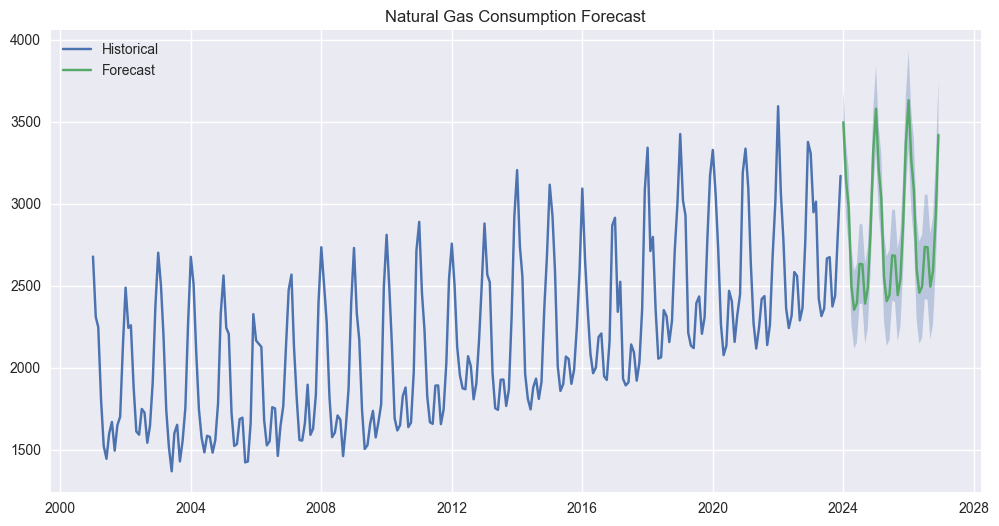

2024-01-01    3495.597054
2024-02-01    3141.369726
2024-03-01    2978.312808
2024-04-01    2496.521731
2024-05-01    2353.181203
2024-06-01    2391.455518
2024-07-01    2632.787436
2024-08-01    2630.492839
2024-09-01    2390.449768
2024-10-01    2485.316555
2024-11-01    2829.545204
2024-12-01    3315.817220
2025-01-01    3578.578023
2025-02-01    3203.306263
2025-03-01    3033.318185
2025-04-01    2549.244274
2025-05-01    2405.151875
2025-06-01    2443.178554
2025-07-01    2684.428912
2025-08-01    2682.107453
2025-09-01    2442.055534
2025-10-01    2536.919406
2025-11-01    2881.147096
2025-12-01    3367.418796
2026-01-01    3630.179495
2026-02-01    3254.907700
2026-03-01    3084.919611
2026-04-01    2600.845696
2026-05-01    2456.753296
2026-06-01    2494.779975
2026-07-01    2736.030332
2026-08-01    2733.708873
2026-09-01    2493.656955
2026-10-01    2588.520827
2026-11-01    2932.748517
2026-12-01    3419.020217
Freq: MS, dtype: float64


In [17]:
# Number of periods to forecast (e.g., next 36 months)
forecast_steps = 36

# Generate forecast
forecast = best_results.get_forecast(steps=forecast_steps)

# Forecast mean
forecast_mean = forecast.predicted_mean

# Confidence intervals
forecast_ci = forecast.conf_int()

# Create forecast index
forecast_index = pd.date_range(
    start=y.index[-1],
    periods=forecast_steps + 1,
    freq="MS"
)[1:]

# Convert to Series with correct index
forecast_series = pd.Series(forecast_mean.values, index=forecast_index)

# Add forecast to dataframe
df_forecast = pd.DataFrame({
    "Actual": y,
})

# Plot
plt.figure(figsize=(12,6))

plt.plot(y, label="Historical")
plt.plot(forecast_series, label="Forecast")

plt.fill_between(
    forecast_index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("Natural Gas Consumption Forecast")
plt.legend()
plt.show()

print(forecast_series)